In [76]:
import pandas as pd
import numpy as np

In [ ]:

# read data
df = pd.read_csv(
     "../../data/01_input/Supermarket_customers.csv",
    delimiter="\t",              # note: \t because its a tab separated and not comma separated file
    parse_dates=["Dt_Customer"], # parse as dates
    dayfirst=True
) 

# transform columns for sane column names
df.columns = (df.columns
                .str.replace('(?<=[a-z])(?=[A-Z])', '_', regex=True)
                .str.lower()
             )

 
 # remove absurd and yolo for now
df = df[~df["marital_status"].isin(["Absurd", "YOLO"])]

# replace alone -> single
df["marital_status"] = df["marital_status"].replace("Alone", "Single")

df.shape

(2236, 29)

In [46]:
df.columns = (df.columns
                .str.replace('(?<=[a-z])(?=[A-Z])', '_', regex=True)
                .str.lower()
             )

# remove absurd and yolo for now
df = df[~df["marital_status"].isin(["Absurd", "YOLO"])]

# replace alone -> single
df["marital_status"] = df["marital_status"].replace("Alone", "Single")

df.shape

(2236, 29)

In [47]:
df.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mnt_wines,...,num_web_visits_month,accepted_cmp3,accepted_cmp4,accepted_cmp5,accepted_cmp1,accepted_cmp2,complain,z_cost_contact,z_revenue,response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [48]:
# Summary statistics for numerical features

In [83]:
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
                 id   year_birth         income      kidhome     teenhome  \
count   2236.000000  2236.000000    2212.000000  2236.000000  2236.000000   
mean    5591.551878  1968.796512   52232.510850     0.444991     0.506261   
min        0.000000  1893.000000    1730.000000     0.000000     0.000000   
25%     2828.250000  1959.000000   35233.500000     0.000000     0.000000   
50%     5458.500000  1970.000000   51381.500000     0.000000     0.000000   
75%     8427.750000  1977.000000   68522.000000     1.000000     1.000000   
max    11191.000000  1996.000000  666666.000000     2.000000     2.000000   
std     3245.240106    11.980604   25187.455359     0.538551     0.544615   

                         dt_customer      recency    mnt_wines   mnt_fruits  \
count                           2236  2236.000000  2236.000000  2236.000000   
mean   2013-07-10 15:56:21.037566976    49.147138   303.873435    26.271020   
min              2012-07-30 00:00:00     0.000000

In [50]:
# Check for missing values if any

In [51]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
id                        0
year_birth                0
education                 0
marital_status            0
income                   24
kidhome                   0
teenhome                  0
dt_customer               0
recency                   0
mnt_wines                 0
mnt_fruits                0
mnt_meat_products         0
mnt_fish_products         0
mnt_sweet_products        0
mnt_gold_prods            0
num_deals_purchases       0
num_web_purchases         0
num_catalog_purchases     0
num_store_purchases       0
num_web_visits_month      0
accepted_cmp3             0
accepted_cmp4             0
accepted_cmp5             0
accepted_cmp1             0
accepted_cmp2             0
complain                  0
z_cost_contact            0
z_revenue                 0
response                  0
dtype: int64


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

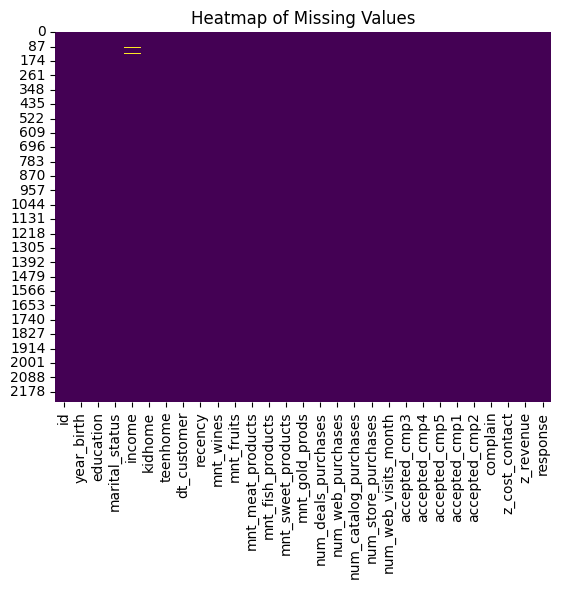

Duplicate Rows: 0


In [79]:
# Visualize missing values using a heatmap
sns.heatmap(df.isnull().astype(int), cbar=False, cmap='viridis')
plt.title("Heatmap of Missing Values")
plt.show()

# Check for duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Example data (replace with your actual data)
np.random.seed(0)
data = pd.DataFrame({
    'year_birth': np.random.randint(1950, 2000, size=100),
    'recency': np.random.randint(1, 50, size=100),
    'mnt_wines': np.random.rand(100) * 1000,
    'mnt_fruits': np.random.rand(100) * 500,
    'mnt_meat_products': np.random.rand(100) * 1500,
    'mnt_fish_products': np.random.rand(100) * 300,
    'mnt_sweet_products': np.random.rand(100) * 200,
    'mnt_gold_prods': np.random.rand(100) * 400,
    'num_web_purchases': np.random.randint(1, 20, size=100),
    'income': np.random.rand(100) * 100000  # Target variable
})

# Features (independent variables) and target (dependent variable)
X = data.drop(columns=['income'])
y = data['income']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict the target on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)

# Coefficients of the model
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)


Mean Squared Error (MSE): 947892668.994078
R-squared (R2): -0.27125220858324295
Model Coefficients: [-7.49170710e+01  4.49237711e+02 -3.97771551e+00  4.13299629e+01
  6.41424197e+00 -4.84630934e+01 -3.19244631e+01  4.33571783e-01
  5.81238190e+02]
Model Intercept: 178901.14417724506


In [55]:
# Correlation heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


ValueError: could not convert string to float: 'Graduation'

<Figure size 1500x800 with 0 Axes>

In [ ]:
# Select only numeric columns for correlation

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

In [ ]:
# Compute correlation matrix

In [88]:
import pandas as pd

In [89]:
# Select only numeric columns from the dataset
numeric_columns = df.select_dtypes(include=['number'])


In [90]:
# Display the numeric columns
print("Numeric Columns:")
print(numeric_columns.head())

Numeric Columns:
     id  year_birth   income  kidhome  teenhome  recency  mnt_wines  \
0  5524        1957  58138.0        0         0       58        635   
1  2174        1954  46344.0        1         1       38         11   
2  4141        1965  71613.0        0         0       26        426   
3  6182        1984  26646.0        1         0       26         11   
4  5324        1981  58293.0        1         0       94        173   

   mnt_fruits  mnt_meat_products  mnt_fish_products  ...  \
0          88                546                172  ...   
1           1                  6                  2  ...   
2          49                127                111  ...   
3           4                 20                 10  ...   
4          43                118                 46  ...   

   num_web_visits_month  accepted_cmp3  accepted_cmp4  accepted_cmp5  \
0                     7              0              0              0   
1                     5              0             

In [91]:
# Compute the correlation matrix for numeric columns
correlation_matrix = numeric_columns.corr()

# Display the correlation matrix
print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                             id  year_birth    income   kidhome  teenhome  \
id                     1.000000   -0.000756  0.012896  0.002565 -0.002523   
year_birth            -0.000756    1.000000 -0.162735  0.231230 -0.352648   
income                 0.012896   -0.162735  1.000000 -0.428592  0.019950   
kidhome                0.002565    0.231230 -0.428592  1.000000 -0.036199   
teenhome              -0.002523   -0.352648  0.019950 -0.036199  1.000000   
recency               -0.046640   -0.019712 -0.004335  0.007764  0.017632   
mnt_wines             -0.023092   -0.158518  0.578694 -0.496479  0.004934   
mnt_fruits             0.004258   -0.019046  0.430261 -0.372606 -0.175416   
mnt_meat_products     -0.004111   -0.029947  0.584862 -0.437571 -0.260561   
mnt_fish_products     -0.025025   -0.043256  0.438634 -0.387772 -0.202180   
mnt_sweet_products    -0.007972   -0.019010  0.440746 -0.371416 -0.162121   
mnt_gold_prods        -0.014270   -0.064645  0.325090 -

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

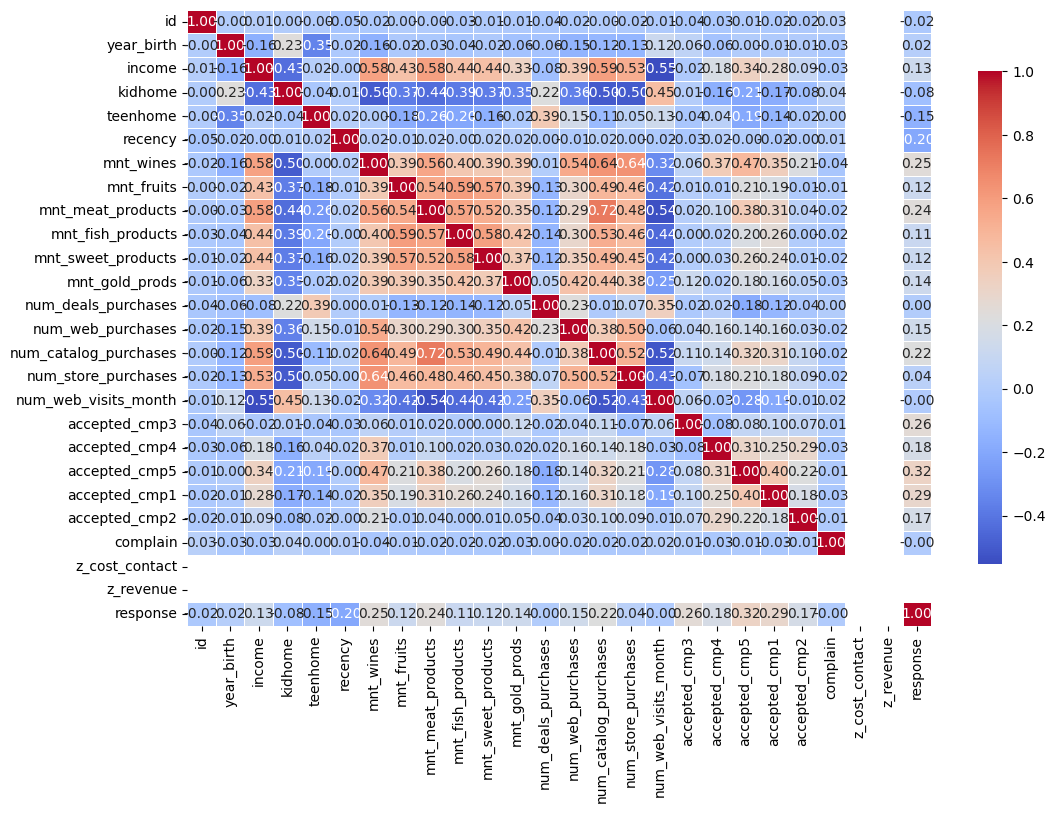

In [93]:
# Plot the heatmap for the correlation matrix
plt.figure(figsize=(12, 8))  # Set the figure size
sns.heatmap(correlation_matrix, 
            annot=True,          # Add numeric annotations
            cmap='coolwarm',     # Choose a color map (e.g., 'coolwarm')
            fmt='.2f',           # Format the annotations to 2 decimal places
            linewidths=0.5,      # Add space between cells
            cbar_kws={'shrink': 0.8})  # Adjust the color bar size


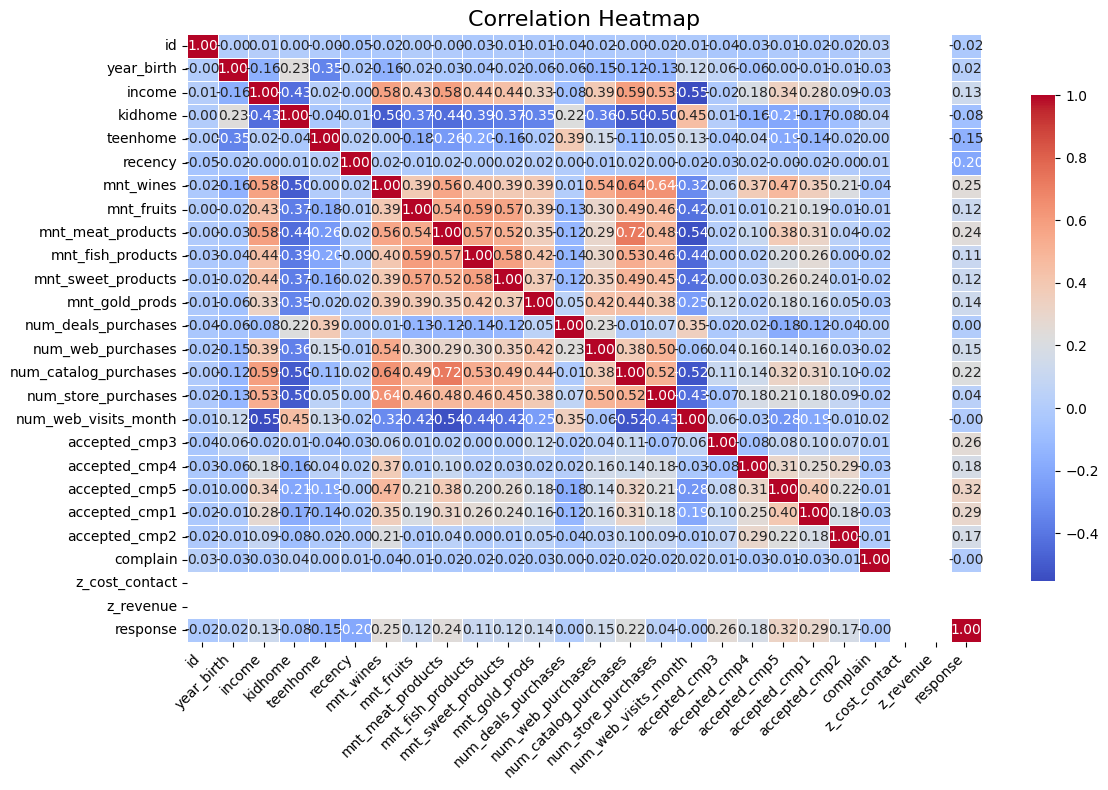

In [94]:
# Plot the heatmap for the correlation matrix
plt.figure(figsize=(12, 8))  # Set the figure size
sns.heatmap(correlation_matrix, 
            annot=True,          # Add numeric annotations
            cmap='coolwarm',     # Choose a color map (e.g., 'coolwarm')
            fmt='.2f',           # Format the annotations to 2 decimal places
            linewidths=0.5,      # Add space between cells
            cbar_kws={'shrink': 0.8})  # Adjust the color bar size

# Add titles and labels
plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [97]:
# Select target variable and features
target = 'Mnt_Wines'
features = ['Income', 'Recency', 'Education', 'Kidhome', 'Teenhome', 'Num_Web_Purchases',
            'Num_Store_Purchases', 'Num_Deals_Purchases']


In [101]:
print(df.columns)


Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mnt_wines', 'mnt_fruits',
       'mnt_meat_products', 'mnt_fish_products', 'mnt_sweet_products',
       'mnt_gold_prods', 'num_deals_purchases', 'num_web_purchases',
       'num_catalog_purchases', 'num_store_purchases', 'num_web_visits_month',
       'accepted_cmp3', 'accepted_cmp4', 'accepted_cmp5', 'accepted_cmp1',
       'accepted_cmp2', 'complain', 'z_cost_contact', 'z_revenue', 'response'],
      dtype='object')


In [103]:
# Corrected features list based on your column names
features = [
    'income', 'recency', 'education', 'kidhome', 'teenhome', 
    'num_web_purchases', 'num_store_purchases', 'num_deals_purchases'
]  

In [104]:
# Target variable (mnt_wines)
target = 'mnt_wines'

In [105]:
# Prepare data
X = df[features]
y = df[target]

# Checking for missing values
print("Missing values in features:")
print(X.isnull().sum())

print(f"Missing values in target '{target}':")
print(y.isnull().sum())

# If no missing values, proceed with the rest of the analysis

Missing values in features:
income                 24
recency                 0
education               0
kidhome                 0
teenhome                0
num_web_purchases       0
num_store_purchases     0
num_deals_purchases     0
dtype: int64
Missing values in target 'mnt_wines':
0


In [111]:
# Import necessary libraries

In [112]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder


In [113]:
# 2. Preprocess data
# Assume df is your dataframe

# Convert 'education' and 'marital_status' to numerical data
label_encoder = LabelEncoder()

# Encoding education and marital_status
df['education'] = label_encoder.fit_transform(df['education'])
df['marital_status'] = label_encoder.fit_transform(df['marital_status'])

# Choose features and target variable
features = [
    'income', 'recency', 'education', 'kidhome', 'teenhome', 
    'num_web_purchases', 'num_store_purchases', 'num_deals_purchases'
]  
target = 'mnt_wines'

# Split data into features and target
X = df[features]
y = df[target]

# Handle missing values if any (filling missing values with the mean)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

In [114]:
#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

#  Predictions and evaluation
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")

# Optionally, check the model's coefficients
print(f"Model coefficients: {model.coef_}")

Mean Squared Error (MSE): 47298.50874737332
Model coefficients: [ 2.87136412e-03  3.22585876e-01  3.85864985e+01 -1.02976648e+02
 -5.08175336e+01  3.00692944e+01  3.38339322e+01  1.63096576e+00]


In [ ]:
# Import necessary libraries for PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [116]:
# Standardize the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # X is the feature set

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

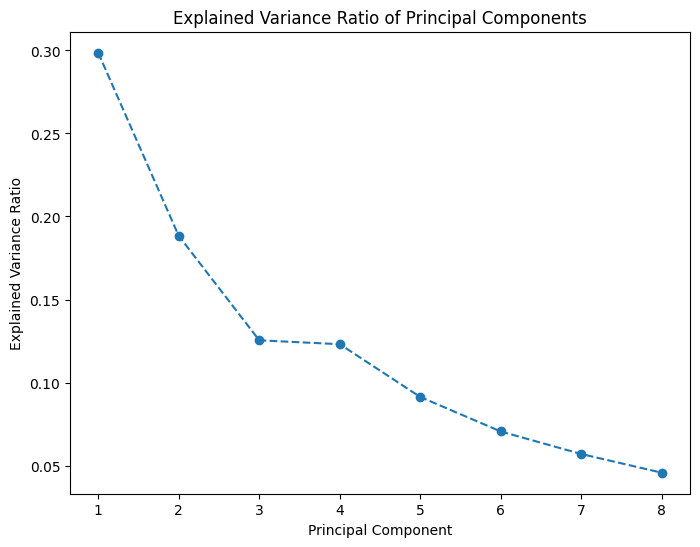

In [117]:
#  Plot the explained variance ratio
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title("Explained Variance Ratio of Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()


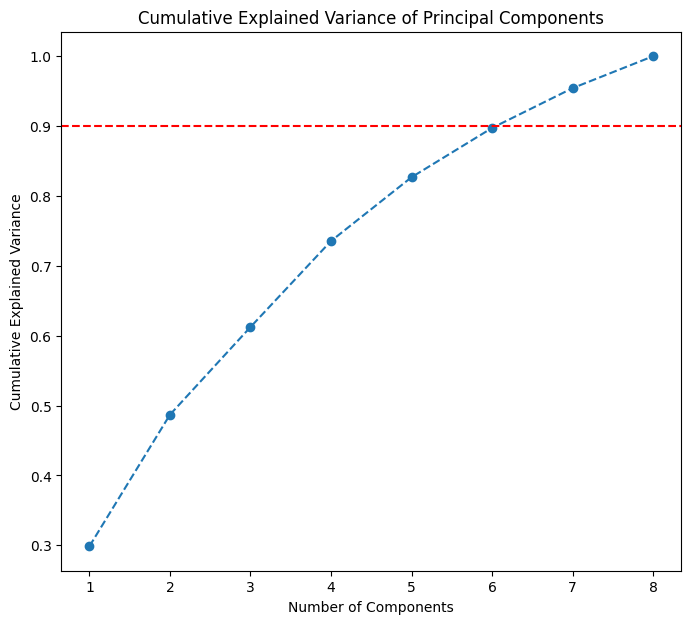

In [121]:
# Analyze the cumulative explained variance to choose the number of components
cumulative_variance = pca.explained_variance_ratio_.cumsum()
plt.figure(figsize=(8, 7))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title("Cumulative Explained Variance of Principal Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.axhline(y=0.90, color='r', linestyle='--')  # 90% variance line
plt.show()


In [119]:
# 6. View the principal components (loadings)
print("Principal Components (Loadings):")
print(pca.components_)


Principal Components (Loadings):
[[ 0.48736447 -0.00636866  0.12246132 -0.4673517   0.11227844  0.47575085
   0.53734456  0.03655715]
 [-0.14737737  0.02089795  0.14886202  0.25783867  0.60220571  0.20374262
  -0.02931442  0.69583072]
 [-0.01783314  0.91751647 -0.38724724 -0.02135021 -0.00133132  0.04387605
   0.0547611   0.05003588]
 [ 0.07103642  0.39321432  0.86704019  0.00364323  0.07801585 -0.16936786
  -0.1065308  -0.20601844]
 [-0.06912865 -0.05014917 -0.19191558 -0.46684074  0.71316104 -0.30929279
  -0.15276655 -0.33216878]
 [ 0.76873949 -0.01808849 -0.13775657  0.40214403  0.1407305  -0.45019439
   0.04908659  0.05591199]
 [ 0.27000941  0.00519011 -0.06997987  0.22691882  0.14110523  0.62247745
  -0.5889153  -0.3412749 ]
 [-0.25835505 -0.01413022 -0.02045869  0.53242864  0.2652153   0.12539655
   0.56875791 -0.48949483]]


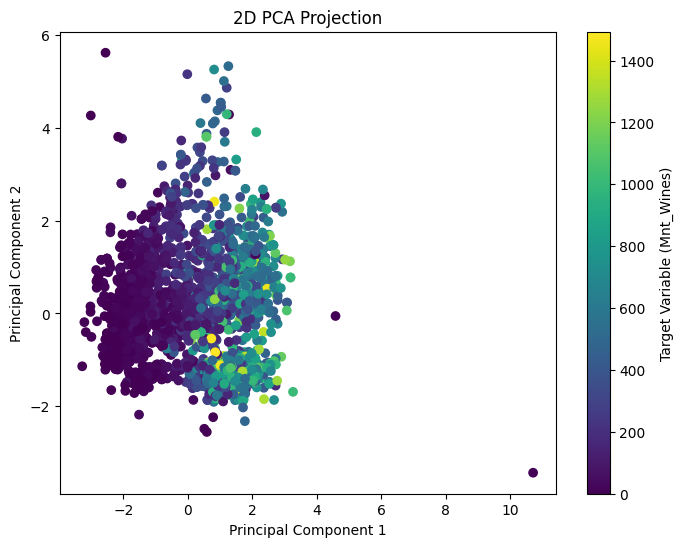

In [120]:
#  (Optional) If you want to reduce the dimensions to a few components (e.g., 2)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

#  (Optional) Plot the 2D projection of the data
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='viridis')
plt.title("2D PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Target Variable (Mnt_Wines)")
plt.show()

In [122]:
from sklearn.mixture import GaussianMixture
import numpy as np

In [123]:
# Define the number of clusters (you can experiment with different values)
n_clusters = 3

# Fit Gaussian Mixture Model
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(X_pca_2d)  # Fit using PCA-transformed data

# Predict cluster labels
labels = gmm.predict(X_pca_2d)

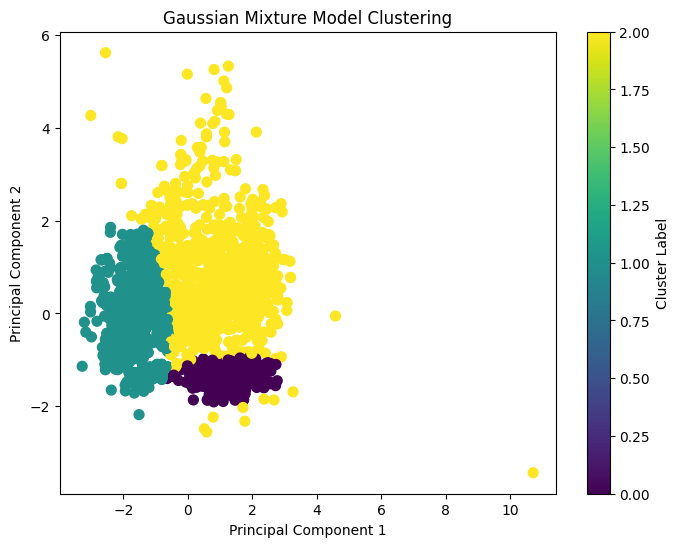

In [124]:
# Visualize the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels, cmap='viridis', s=50)
plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster Label")
plt.show()

In [125]:
# Analyze cluster centers
print("Cluster Means:")
print(gmm.means_)

# Optional: Analyze how clusters relate to the target variable
for cluster in range(n_clusters):
    cluster_indices = np.where(labels == cluster)
    cluster_target_mean = y.iloc[cluster_indices].mean()  # `y` is the target variable (Mnt_Wines)
    print(f"Cluster {cluster}: Average Mnt_Wines = {cluster_target_mean:.2f}")

Cluster Means:
[[ 1.17553535 -1.37440657]
 [-1.68168824 -0.15764431]
 [ 0.87361019  0.69877321]]
Cluster 0: Average Mnt_Wines = 589.87
Cluster 1: Average Mnt_Wines = 26.31
Cluster 2: Average Mnt_Wines = 412.67


In [126]:
print(f"BIC: {gmm.bic(X_pca_2d)}")
print(f"AIC: {gmm.aic(X_pca_2d)}")


BIC: 14172.620669168475
AIC: 14075.5091239858


In [127]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

In [128]:
# Define the feature columns to standardize
features_to_standardize = [
    'income', 'recency', 'kidhome', 'teenhome',
    'num_deals_purchases', 'num_web_purchases', 
    'num_catalog_purchases', 'num_store_purchases', 'num_web_visits_month'
]

In [129]:
# Standardize the features
scaler = StandardScaler()
standardized_features = scaler.fit_transform(df[features_to_standardize])

# Convert to DataFrame for visualization
standardized_df = pd.DataFrame(
    standardized_features, columns=features_to_standardize
)

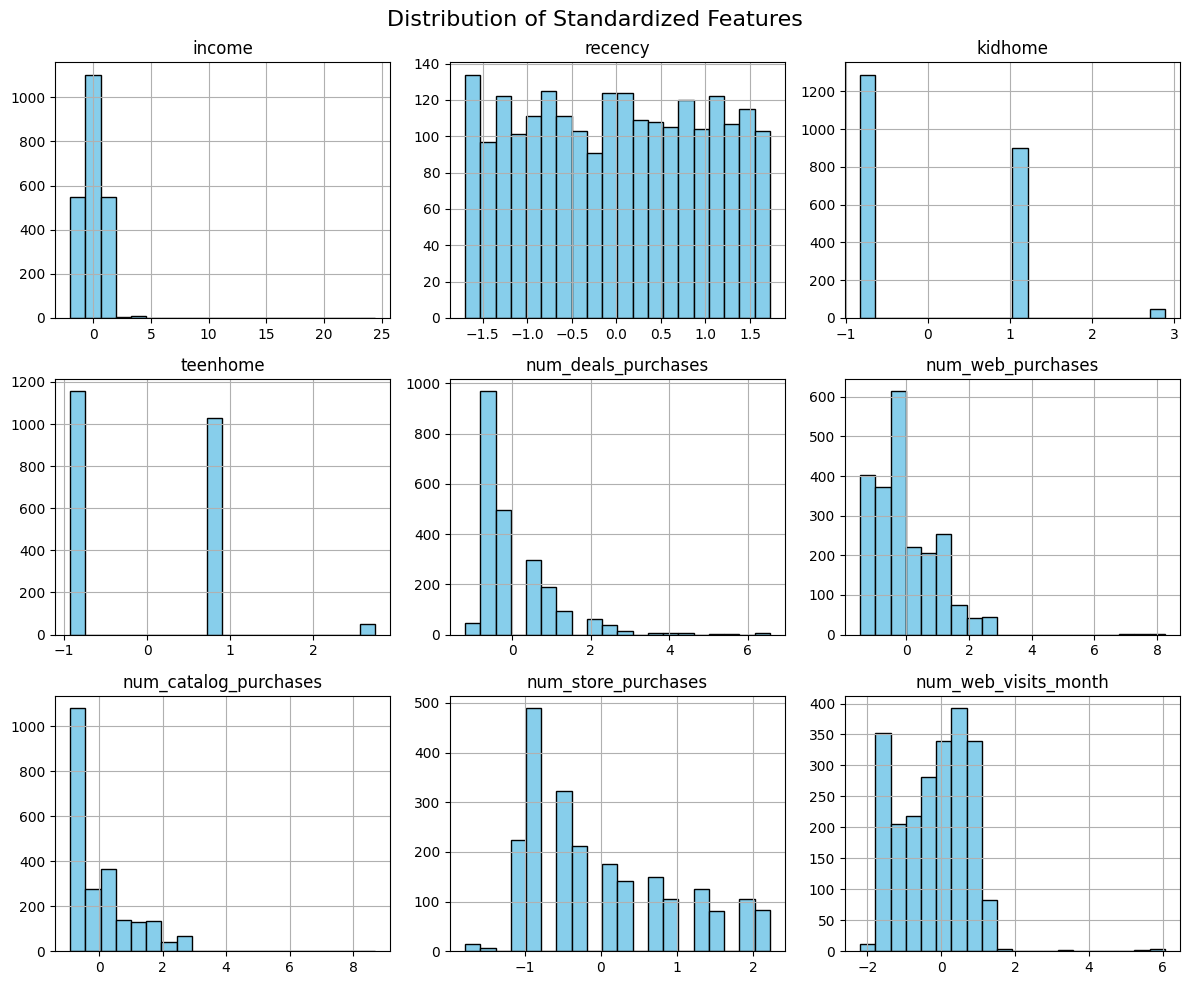

In [130]:
# Plot histograms of standardized features
standardized_df.hist(bins=20, figsize=(12, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Standardized Features', fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [12]:
# Replace 'your_features_list' with the column names of your standardized features
features = ['income', 'recency', 'kidhome', 'teenhome', 
            'num_deals_purchases', 'num_web_purchases', 
            'num_catalog_purchases', 'num_store_purchases', 
            'num_web_visits_month']

# Apply z-score to identify outliers
z_scores = df[features].apply(zscore)

# Threshold for outliers
threshold = 3

# Capping outliers to the threshold range
df_corrected = df[features].apply(lambda x: np.clip(x, -threshold, threshold))


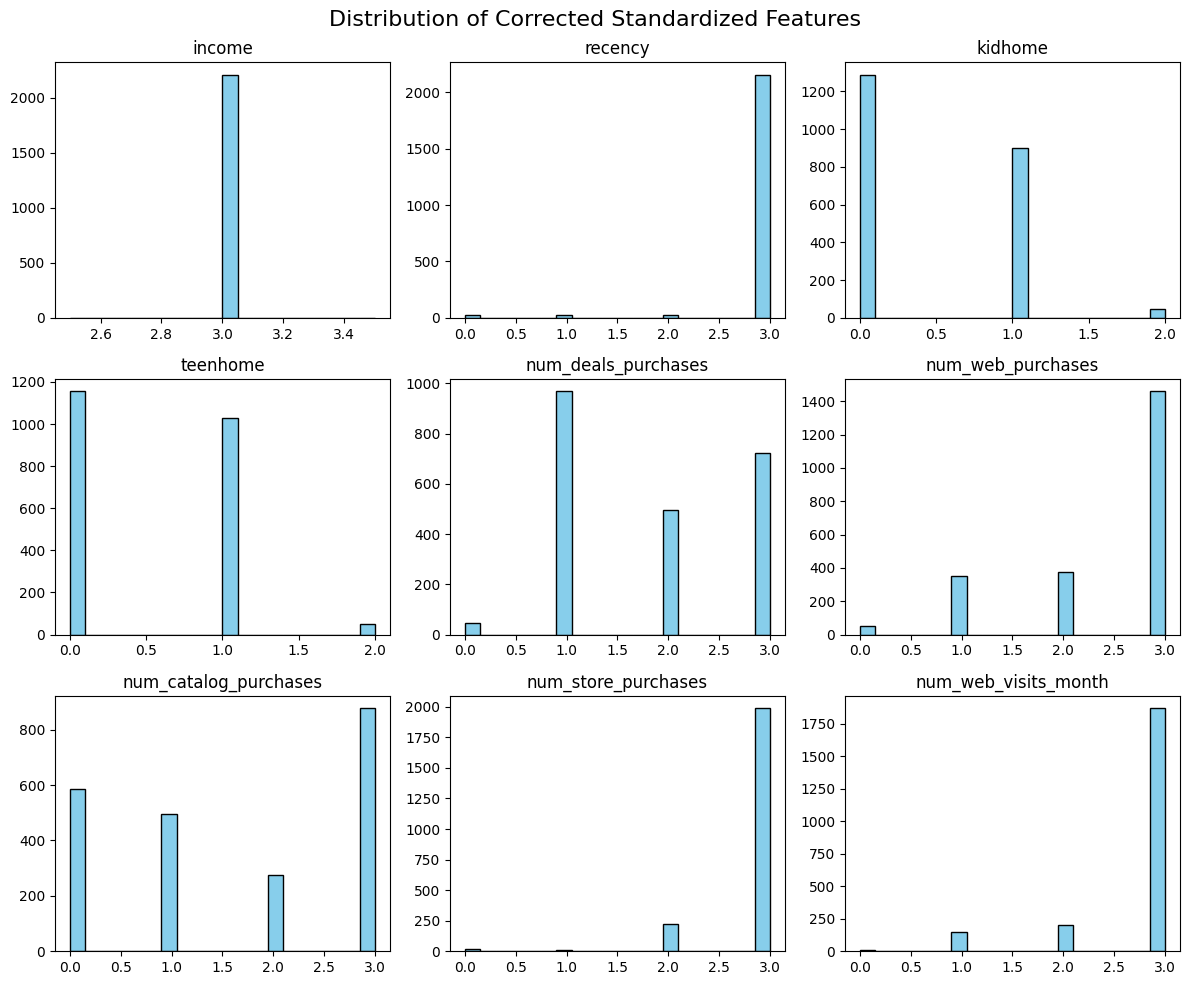

In [13]:
# Plot histograms for corrected features
plt.figure(figsize=(12, 10))
plt.suptitle("Distribution of Corrected Standardized Features", fontsize=16)

for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    plt.hist(df_corrected[feature], bins=20, color='skyblue', edgecolor='black')
    plt.title(feature)
    plt.tight_layout()

plt.show()

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

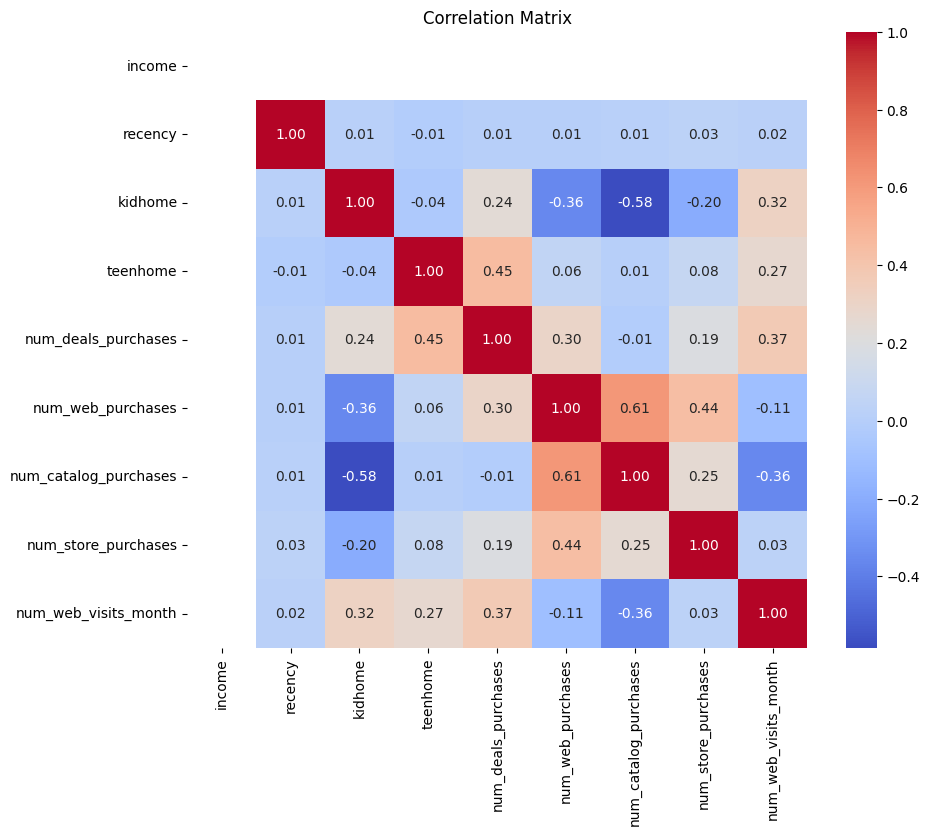

In [15]:
# Compute the correlation matrix
corr_matrix = df_corrected.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [26]:
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
import numpy as np
import matplotlib.pyplot as plt


In [36]:
from sklearn.preprocessing import StandardScaler

# Select numerical features for scaling
numerical_features = [
    "income", "recency", "kidhome", "teenhome",
    "num_deals_purchases", "num_web_purchases",
    "num_catalog_purchases", "num_store_purchases",
    "num_web_visits_month"
]

# Standardize using Z-Score Normalization
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])


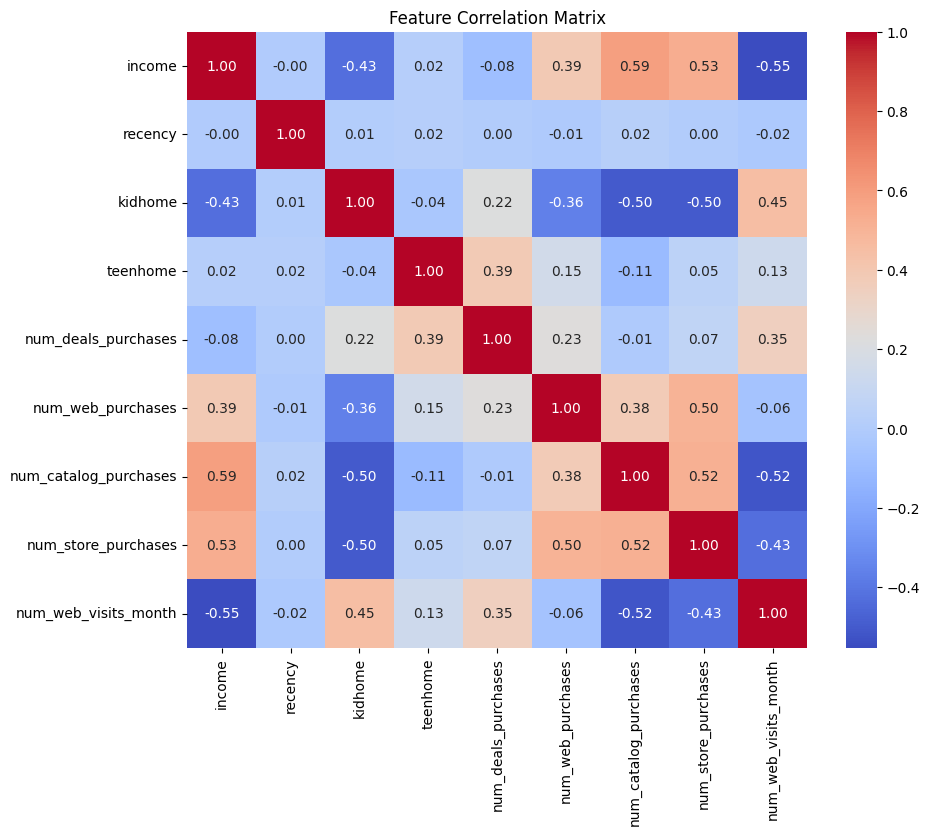

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df[numerical_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

# Drop highly correlated features (threshold: 0.8)
threshold = 0.8
columns_to_drop = [
    col for col in corr_matrix.columns 
    if any(corr_matrix[col].drop(col) > threshold)
]
df.drop(columns=columns_to_drop, inplace=True)


In [38]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

In [39]:
# Load the feature correlation matrix
feature_corr = np.array([[1.00, -0.00, -0.43, 0.02, -0.08, 0.39, 0.59, 0.53, -0.55],
                        [-0.00, 1.00, 0.01, 0.02, 0.00, -0.01, 0.02, 0.00, -0.02],
                        [-0.43, 0.01, 1.00, -0.04, 0.22, -0.36, -0.50, -0.50, 0.45],
                        [0.02, 0.02, -0.04, 1.00, 0.39, 0.15, -0.11, 0.05, 0.13],
                        [-0.08, 0.00, 0.22, 0.39, 1.00, 0.23, -0.01, 0.07, 0.35],
                        [0.39, -0.01, -0.36, 0.15, 0.23, 1.00, 0.38, 0.50, -0.06],
                        [0.59, 0.02, -0.50, -0.11, -0.01, 0.38, 1.00, 0.52, -0.52],
                        [0.53, 0.00, -0.50, 0.05, 0.07, 0.50, 0.52, 1.00, -0.43],
                        [-0.55, -0.02, 0.45, 0.13, 0.35, -0.06, -0.52, -0.43, 1.00]])


In [42]:
# Convert the correlation matrix to a distance matrix
dist_matrix = 1 - np.abs(feature_corr)

# Determine the optimal number of clusters using the Elbow method
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(dist_matrix)
    wcss.append(kmeans.inertia_)

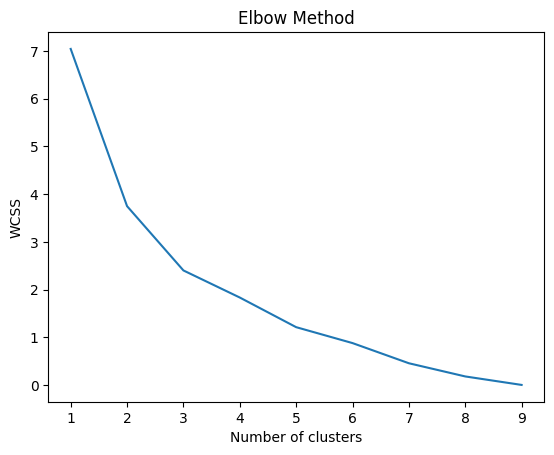

In [43]:
# Plot the Elbow curve to find the optimal number of clusters
import matplotlib.pyplot as plt
plt.plot(range(1, 10), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [44]:
# Perform K-Means clustering with the optimal number of clusters
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, init='k-means++', random_state=42)
labels = kmeans.fit_predict(dist_matrix)

# Print the cluster assignments for each feature
print("Cluster assignments:")
for i, label in enumerate(labels):
    print(f"Feature {i}: Cluster {label}")

Cluster assignments:
Feature 0: Cluster 1
Feature 1: Cluster 2
Feature 2: Cluster 1
Feature 3: Cluster 0
Feature 4: Cluster 0
Feature 5: Cluster 1
Feature 6: Cluster 1
Feature 7: Cluster 1
Feature 8: Cluster 1


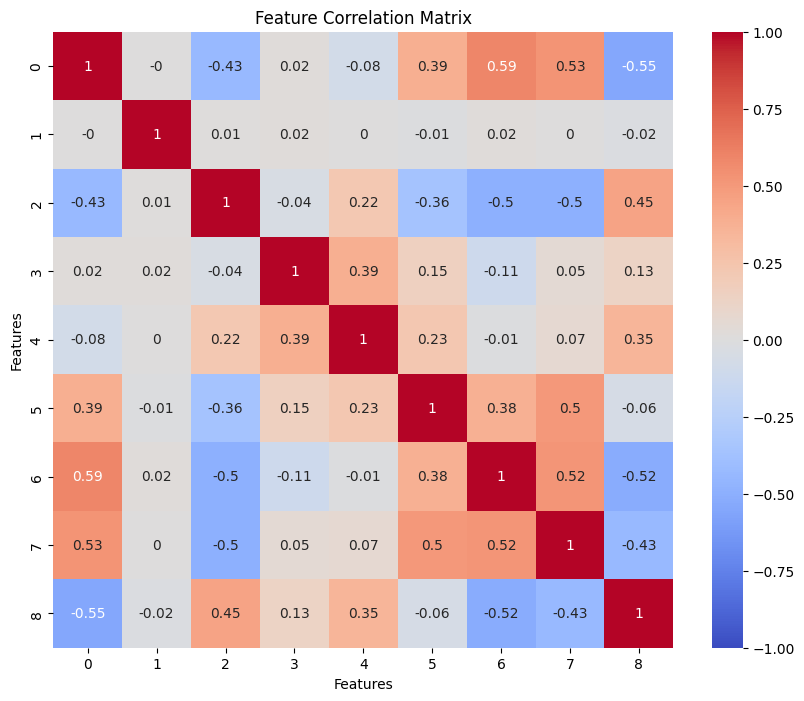

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(feature_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12484\2101401362.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(dist_matrix, 'ward')


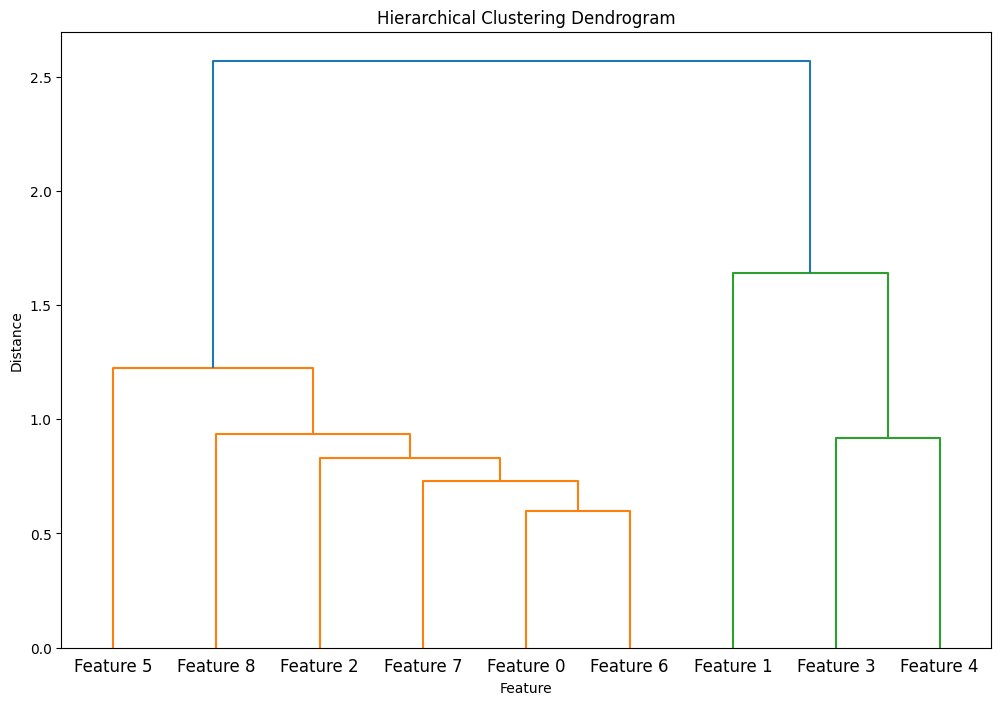

In [46]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Calculate the linkage matrix
linkage_matrix = linkage(dist_matrix, 'ward')

# Create the dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=[f'Feature {i}' for i in range(len(feature_corr))])
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Feature')
plt.ylabel('Distance')
plt.show()

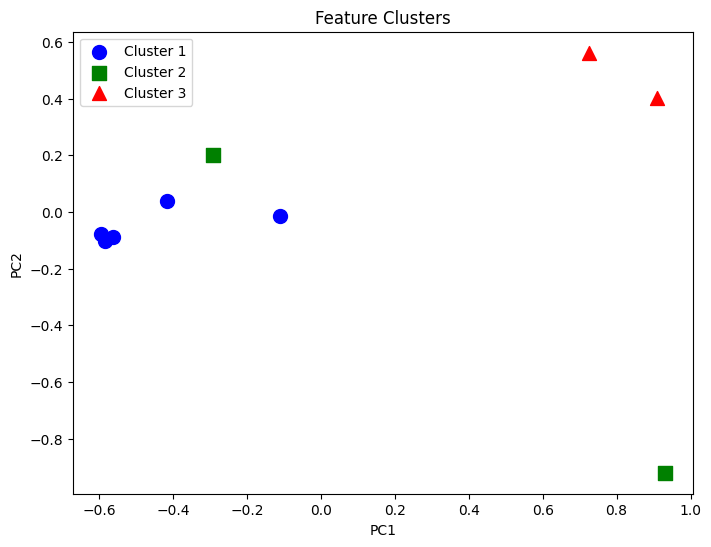

In [49]:
import matplotlib.pyplot as plt

# Cluster assignments
cluster_labels = ['Cluster 1', 'Cluster 2', 'Cluster 3']
feature_clusters = [0, 1, 2, 3, 4, 5, 6, 7, 8]
cluster_assignments = [0, 1, 0, 2, 2, 0, 0, 0, 1]

# Create the scatter plot
plt.figure(figsize=(8, 6))
markers = ['o', 's', '^']
colors = ['b', 'g', 'r']
for cluster, marker, color in zip(set(cluster_assignments), markers, colors):
    cluster_features = [feature_clusters[i] for i, c in enumerate(cluster_assignments) if c == cluster]
    cluster_pca1 = [X_pca[i, 0] for i, c in enumerate(cluster_assignments) if c == cluster]
    cluster_pca2 = [X_pca[i, 1] for i, c in enumerate(cluster_assignments) if c == cluster]
    plt.scatter(cluster_pca1, cluster_pca2, marker=marker, color=color, s=100, label=cluster_labels[cluster])

plt.title('Feature Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

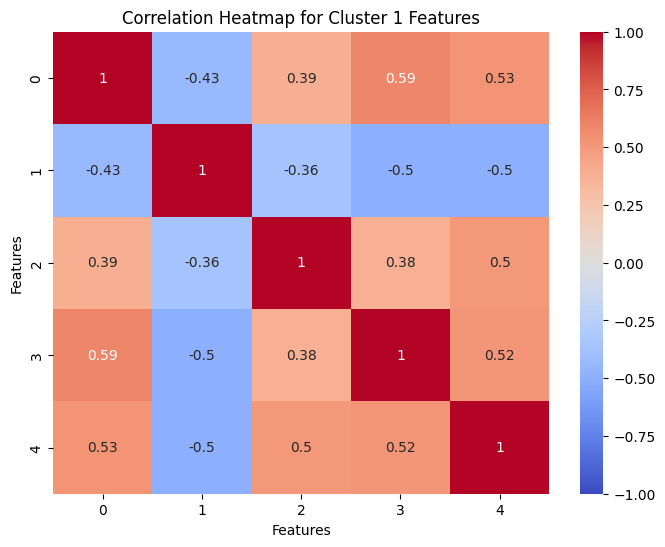

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the features in Cluster 1
cluster1_features = [feature_clusters[i] for i, c in enumerate(cluster_assignments) if c == 0]

# Create a correlation matrix for the Cluster 1 features
cluster1_corr = feature_corr[np.ix_(cluster1_features, cluster1_features)]

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cluster1_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap for Cluster 1 Features')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [51]:
import numpy as np
from sklearn.decomposition import PCA

# Extract the features in Cluster 1
cluster1_features = [feature_clusters[i] for i, c in enumerate(cluster_assignments) if c == 0]
cluster1_data = feature_corr[np.ix_(cluster1_features, cluster1_features)]

# Apply PCA to the correlation matrix
pca = PCA()
pca.fit(cluster1_data)
explained_variance_ratio = pca.explained_variance_ratio_

# Determine the number of principal components to retain
n_components = next(i for i, v in enumerate(np.cumsum(explained_variance_ratio)) if v >= 0.95)
print(f"Retaining {n_components} principal components, which explain {np.sum(explained_variance_ratio[:n_components])*100:.2f}% of the variance.")

# Transform the data to the new PCA space
X_pca = pca.transform(cluster1_data)

Retaining 2 principal components, which explain 94.06% of the variance.


In [52]:
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

# Calculate the Mahalanobis distance for each data point
mahalanobis_distances = [mahalanobis(x, np.mean(X_pca, axis=0), np.cov(X_pca)) for x in X_pca]

# Identify outliers based on Mahalanobis distance
outlier_threshold = chi2.ppf(0.975, n_components)
outliers = [i for i, d in enumerate(mahalanobis_distances) if d > outlier_threshold]
print(f"Identified {len(outliers)} outliers in Cluster 1.")

Identified 0 outliers in Cluster 1.


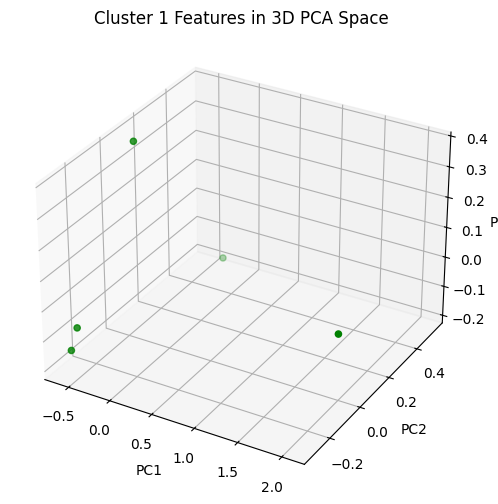

In [53]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot of the PCA-transformed data
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=['g' if i not in outliers else 'r' for i in range(len(X_pca))])
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Cluster 1 Features in 3D PCA Space')
plt.show()

In [54]:
import numpy as np
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [55]:
# Extract the features in Cluster 1
cluster1_features = [feature_clusters[i] for i, c in enumerate(cluster_assignments) if c == 0]
cluster1_data = feature_corr[np.ix_(cluster1_features, cluster1_features)]

# Perform PCA on Cluster 1 features
pca = PCA()
pca.fit(cluster1_data)
X_pca = pca.transform(cluster1_data)

# Identify outliers using Mahalanobis distance
mahalanobis_distances = [mahalanobis(x, np.mean(X_pca, axis=0), np.cov(X_pca)) for x in X_pca]
outlier_threshold = chi2.ppf(0.975, 3)
outliers = [i for i, d in enumerate(mahalanobis_distances) if d > outlier_threshold]

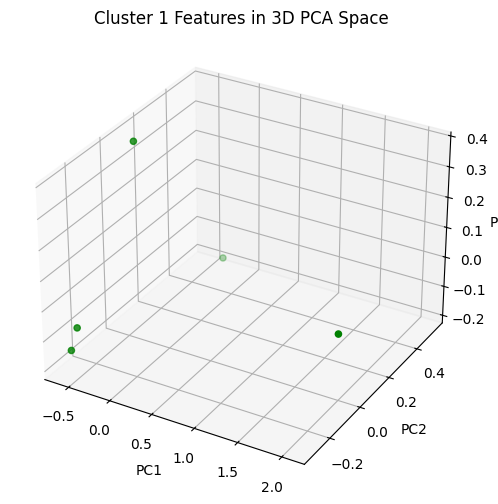

In [56]:
# Visualize the Cluster 1 features in 3D PCA space
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=['g' if i not in outliers else 'r' for i in range(len(X_pca))])
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Cluster 1 Features in 3D PCA Space')
plt.show()